# RNA-count noise simulation

To demonstrate that it is possible to reconstruct a simple trajectory with scTOP even in the presence of noise, this notebook recreates the double-cusp landscape of `noise simulations.ipynb` and implements a realistic noise-adding pipeline for converting simulated z-scores into noisy RNA counts, which are then projected onto cell fate space with scTOP.

Overview of the noise-adding process:
1. Converts a z-score simulation state back to an RNA count simulation (working backwards through the processing). `top.process` only preserves each gene's rank order within a cell. To reconstructing "RNA counts" from a z-score state, we borrow those from real data. For estimating count magnitudes, we use a real developmental lung scRNA-seq atlas (`gastrula to pup lung.h5ad`, mouse, raw counts). For each of the three cell types (AT1, AT2, early epithelium/progenitor) we compute a mean real count profile. At a given simulation step, we mix these three profiles using the step's attractor weights, then assign counts to genes by matching the simulated gene rank order to the (sorted) mixed reference profile, rescaled to an assumed library size of 5,000 reads/cell (typical real-world sequencing depth; see histogram below).
2. Simulates biological variability with gamma-Poisson (Splat-like, https://pmc.ncbi.nlm.nih.gov/articles/PMC5596896/) noise. Biological coefficient of variation (`bio_cv`is the tunable noise level (default 0.1).
3. Simulates technical noise with Splatter-style expression-dependent logistic dropout (lower-expressed genes drop out more often). `dropout_shift` shifts the logistic midpoint to control the overall dropout rate (default 0).
4. Process the noisy counts with `top.process`/`top.score` again (using the same atlas as used for the lungMAP analysis) and plots the results the same way as the double-cusp cell (contour plot).
5. Vary `bio_cv` and `dropout_shift` (default, and one step lower/higher each) to get a 3x3 matrix of contour plots, to show the effects of varying levels of noise.

In [1]:
# Import necessary packages

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm, trange
import sctop as top # note: this uses sctop version 1.0.0
from itertools import combinations
from scipy.special import softmax

# Settings for making nice plots

sns.set(context='talk', color_codes=True, palette='deep', style='whitegrid', font_scale=1.2,
        rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in',
            'figure.dpi':100, 'text.usetex':False})

## 1. Load data
Attractor states are the three lung epithelial types (AT1, AT2, early epithelium/progenitor) at P0 from the gastrula-to-pup lung atlas (Qiu et al., 2024), processed with `top.process(..., average=True)`.


In [2]:
import anndata as ad

# Atlas and cell-type map
_noise_real_data = ad.read_h5ad('/Users/maria/github/phenotype-signaling/gastrula to pup lung.h5ad')
_noise_cell_type_map = {'at1': 'Alveolar Type 1 cells',
                        'at2': 'Alveolar Type 2 cells',
                        'early epithelium': 'Lung progenitor cells'}

# Build the scoring basis before loading expression profiles so all simulation
# states are restricted to the genes used by the scoring pipeline.
basis_MCKO, tags_MCKO = top.load_basis('MC-KO', 0)
basis_LD, tags_LD = top.load_basis('LD', 0)
basis_MCKO_cutoff, tags_MCKO_cutoff = top.load_basis('MC-KO', 100)
basis_LD_cutoff, tags_LD_cutoff = top.load_basis('LD', 100)

epithelial_profile = basis_LD_cutoff.loc[:, 'Lung Early Epithelium Cell E12 LD21']
basis_genes = np.intersect1d(basis_MCKO_cutoff.index, basis_LD_cutoff.index)
new_basis = pd.concat([basis_MCKO_cutoff.loc[basis_genes],
                       epithelial_profile.loc[basis_genes]],
                      axis=1)

noise_ref_genes = np.intersect1d(
    np.intersect1d(_noise_real_data.var['feature_name'].values, new_basis.index.values),
    _noise_real_data.var['feature_name'].values)

attractor_profiles = {}
for label, author_type in _noise_cell_type_map.items():
    obs_mask = ((_noise_real_data.obs['author_cell_type'] == author_type)
                & (_noise_real_data.obs['author_day'] == 'P0000')).values
    var_mask = _noise_real_data.var['feature_name'].isin(noise_ref_genes).values
    sub = _noise_real_data[obs_mask][:, var_mask]
    counts = pd.DataFrame(
        sub.layers['raw.X'].toarray().T
        if hasattr(sub.layers['raw.X'], 'toarray') else np.asarray(sub.layers['raw.X']).T,
        index=sub.var['feature_name'].values)
    counts = counts.groupby(level=0).sum()
    attractor_profiles[label] = top.process(counts, average=True).iloc[:, 0]

attractor_states = pd.DataFrame(attractor_profiles).dropna()
attractor_states = attractor_states.loc[noise_ref_genes, ['at1', 'at2', 'early epithelium']]

N, P = attractor_states.shape

/var/folders/7c/b7ghlxj12pv2nv3wb_y9qdz00000gn/T/ipykernel_27914/4009935984.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = counts.groupby(level=0).sum()
/var/folders/7c/b7ghlxj12pv2nv3wb_y9qdz00000gn/T/ipykernel_27914/4009935984.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = counts.groupby(level=0).sum()
/var/folders/7c/b7ghlxj12pv2nv3wb_y9qdz00000gn/T/ipykernel_27914/4009935984.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

## 2. Define functions and classes for simulating attractor networks

Unmodified from `noise simulations.ipynb` -- gradient functions, coordinate transforms, and the `AttractorNetwork` class.

In [3]:
# Define potentials by their gradients and the approximate positions of their attractors

def triple_cusp_grad(x, y, params):
    grad_x = 6*x**5 - 4*x**3 + 2*x + 4*x*y + params['f']
    grad_y = 16*y**3 - 2*y + 2*x**2 + params['k']
    return grad_x, grad_y

def het_flip_grad(x, y, params):
    grad_x = 4*x**3 + 4*x*y + params['f']
    grad_y = 4*y**3 - 3*y**2 + 2*x**2 - 2*y + params['k']
    return grad_x, grad_y

def double_cusp_grad(x, y, params):
    grad_x = 4*x**3 + 8*x*y + params['f']
    grad_y = 4*y**3 - 3*y**2 + 4*x**2 + 2*y - params['k']
    return grad_x, grad_y

triple_cusp_coords = {'y0': 0.345,
                     'x1': 0.838,
                     'y1': -0.537
                    }

# heteroclinic flip:
het_flip_coords = {'y0': 0.82,
                    'x1': 0.964,
                    'y1': -0.877
                   }

# double cusp:
double_cusp_coords = {'y0': 0.085,
                      'x1': 1.349,
                      'y1': -0.911
                      }

In [4]:
# We have some potential of the form V(x, y)
# To calculate V(m), we project between m-space to xy-space
# To find the matrix that transforms between x and m, we need
# translations, rotations, and scaling in 4 dimensions

T = np.array([[1, 0, 0, -1],
              [0, 1, 0, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

Tinv = np.array([[1, 0, 0, 1],
                 [0, 1, 0, 0],
                 [0, 0, 1, 0],
                 [0, 0, 0, 1]])

X = np.array([[1, 0, 0, 0],
              [0, 0, -1, 0],
              [0, 1, 0, 0],
              [0, 0, 0, 1]])

Xinv = np.array([[1, 0, 0, 0],
                 [0, 0, 1, 0],
                 [0, -1, 0, 0],
                 [0, 0, 0, 1]])

sq2 = np.sqrt(2) / 2
psi = np.arcsin(np.sqrt(2/3))

Y = np.array([[sq2, 0, sq2, 0],
              [0, 1, 0, 0],
              [-sq2, 0, sq2, 0],
              [0, 0, 0, 1]])

Yinv = np.array([[sq2, 0, -sq2, 0],
                 [0, 1, 0, 0],
                 [sq2, 0, sq2, 0],
                 [0, 0, 0, 1]])

Z = np.array([[np.cos(psi), -np.sin(psi), 0, 0],
              [np.sin(psi), np.cos(psi), 0, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

M = np.dot(Tinv, np.dot(Xinv, np.dot(Yinv, np.dot(Z, np.dot(Y, np.dot(X, T))))))

# Make adjustments for the positions of the attractors in xy-space
def generate_x_to_m_matrix(y0, x1, y1):
    S = np.array([
        [np.sqrt(2)/(2*x1), 0, 0, 0],
        [0, np.sqrt(3/2)/(y0 - y1), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    T1 = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, -np.sqrt(2)/2 - (y1 * np.sqrt(3/2))/(y0 - y1)],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    theta = (3 * np.pi)/4
    R1 = np.array([
        [np.cos(theta), -np.sin(theta), 0, 0],
        [np.sin(theta), np.cos(theta), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    return np.dot(M, np.dot(R1, np.dot(T1, S)))

def initialize_attractor_vectors(y0, x1, y1):
    attractor0 = np.array([[0],
                           [y0],
                           [0],
                           [1]
                        ])

    attractor1 = np.array([
        [x1],
        [y1],
        [0],
        [1]
    ])

    attractor2 = np.array([
        [-x1],
        [y1],
        [0],
        [1]
    ])

    return (attractor0, attractor1, attractor2)

In [5]:
class AttractorNetwork:
    """
    A class that simulates an attractor-based dynamical system with an evolving energy landscape.
    The system evolves toward stored attractor states under the influence of external gradients.
    """

    def __init__(self, dynamics_args, landscape_args):
        """
        Initialize the attractor network.

        Parameters:
        - dynamics_args: Dictionary containing 'stored_states' (matrix of gene expression profiles) and 'initial_state':

            dynamics_args = {
                'stored_states': attractor states stored as rows in a 2D array,
                'initial_state': the starting gene expression state (1D array)
            }

        - landscape_args: Dictionary containing 'start_params', 'attractor_coords', and 'gradients':

            landscape_args = {
                'start_params': dict of initial parameters for the energy landscape,
                'attractor_coords': coordinates for attractor projections in x-y space,
                'gradients': function returning gradients of the landscape w.r.t. x and y
            }

        """

        self.attractors = dynamics_args['stored_states'].copy()
        self.state = dynamics_args['initial_state'].copy()

        self.params = landscape_args['start_params'].copy()
        self.start_params = landscape_args['start_params']

        self.N = len(self.state)  # Number of elements in the state vector.
        self.temperature = 1 / (2 * self.N) # low temperature, so that there's not too much random jumping

        # Calculate the correlation matrix and its inverse.
        self.corr = (1 / self.N) * self.attractors.dot(self.attractors.T)
        self.inv_corr = np.linalg.inv(self.corr)

        # Unpack the attractor coordinates.
        self.x0, self.y0 = landscape_args['attractor_coords'][0]
        self.x1, self.y1 = landscape_args['attractor_coords'][1]

        self.x_hat = np.array([1, 0, 0, 0])
        self.y_hat = np.array([0, 1, 0, 0])

        x_to_m = generate_x_to_m_matrix(self.y0, self.x1, self.y1)
        self.m_to_x = np.linalg.inv(x_to_m)

        self.hx = np.dot(self.x_hat, self.m_to_x)
        self.hy = np.dot(self.y_hat, self.m_to_x)

        self.gradients = landscape_args['gradients']

        self.rng = np.random.default_rng()

    def dynamics(self):
        """
        Compute the change in the system's state based on attractor dynamics
        and the gradient of the external potential landscape.

        Returns:
        - A vector representing the change in state.
        """

        m_up = (1/self.N)*self.attractors.dot(self.state) # upper index/contravariant
        m_low = self.inv_corr.dot(m_up) # lower index/covariant

        m_low_4d = np.array([*m_low, 1])

        x = np.dot(self.hx, m_low_4d)
        y = np.dot(self.hy, m_low_4d)

        inv_corr_4d = np.vstack((self.inv_corr, np.array([0, 0, 0])))
        inv_corr_4d = np.hstack((inv_corr_4d, np.array([0, 0, 0, 1]).reshape(-1, 1)))

        x_chain = np.dot(self.hx, inv_corr_4d)
        y_chain = np.dot(self.hy, inv_corr_4d)

        grad_x, grad_y = self.gradients(x, y, self.params)

        potential_grad = grad_x*x_chain + grad_y*y_chain
        potential_grad = potential_grad[:3]

        gradient_scale = 10 # adjustment factor to increase effect of gradient

        attraction = self.attractors.T.dot(
            softmax((1/self.temperature)*(m_low - gradient_scale*potential_grad))
        )

        return attraction - self.state


    def update(self):
        """
        Perform a single update of the network state using synchronous or asynchronous dynamics.
        """

        # "asynchronous updates": randomly choose which genes to update each time
        timing_scale = 10
        asynch = self.rng.binomial(1, 1/timing_scale, size=N) # allow 1 in __ genes to update at each step
        self.state += asynch*self.dynamics()/20

        # synchronous updates: all genes update simultaneously
#         self.state += self.dynamics()/20

    def increment_param(self, t, param, signal_bounds, finish_params):
        """
        Increment a specific bifurcation parameter gradually between start and end times.

        Parameters:
        - t: Current simulation time.
        - param: Parameter name to increment (e.g., 'f', 'k').
        - signal_bounds: Dict with 'start' and 'end' times for each parameter.
        - finish_params: Dict of final target values for parameters.
        """

        if (t > signal_bounds['start'][param]) and (t < signal_bounds['end'][param]):
            self.params[param] += (finish_params[param] - self.start_params[param])/(signal_bounds['end'][param] - signal_bounds['start'][param])

    def simulate(self, total_time, signal_bounds, finish_params, recorded_genes=None, add_noise=False):
        """
        Run a full simulation of the network over time, tracking magnetizations and optionally individual genes.

        Parameters:
        - total_time: Duration of the simulation.
        - signal_bounds: Dict specifying start/end times for each parameter change.
        - finish_params: Dict of final values for changing parameters.
        - recorded_genes: List of gene names (indices) to record over time.
        - add_noise: If True, adds dropout and Gaussian noise to measurements.

        Returns:
        - A pandas DataFrame containing time series of order parameters, magnetizations, and recorded genes.
        """

        magnetizations = []

        gene_dict = {}
        if recorded_genes is not None:
            for gene in recorded_genes:
                gene_dict[gene] = []

        t = 0
        time_interval = 1 # in minutes
        while t < total_time:
            # Choose which parameters to increment
            self.increment_param(t, 'f', signal_bounds, finish_params)
            self.increment_param(t, 'k', signal_bounds, finish_params)

            if add_noise: # this just adds noise to the observations, not to the system
                detection_rate = 0.4
                dropout = self.rng.binomial(1, detection_rate, size=N)
                zero_indices = np.where(dropout == 0)[0]

                dropout_state = self.state.T.copy()
                dropout_state.iloc[zero_indices] = -1

                noise = self.rng.standard_normal(size=N)

                magnetizations += [(1/N)*self.attractors.dot(dropout_state + noise)]

            else:
                magnetizations += [(1/N)*self.attractors.dot(self.state.T)]

            if recorded_genes is not None:
                for gene in recorded_genes:
                    gene_dict[gene] += [self.state.loc[gene]]

            self.update()
            t += time_interval

        magnetizations = pd.DataFrame(magnetizations)
        if len(magnetizations.columns[0]) < 2:
            magnetizations = pd.DataFrame(magnetizations, columns=['m{}'.format(index) for index in range(self.attractors.shape[0])])
        order_params = self.inv_corr.dot(magnetizations.T)

        output_df = pd.concat([pd.DataFrame(order_params, index=magnetizations.columns).T, magnetizations, pd.DataFrame(gene_dict)], axis=1)

        if len(magnetizations.columns[0]) < 2:
            output_df = pd.concat([pd.DataFrame(order_params, index=['a{}'.format(index) for index in range(self.attractors.shape[0])]).T,
                                magnetizations, pd.DataFrame(gene_dict)], axis=1)
        return output_df

## 3. Run one double-cusp trial, recording the full gene-level state

`AttractorNetwork.simulate()` only records magnetizations + a few marker genes, not the full z-score vector. This re-implements the same time loop externally (reusing the class unmodified) to capture `network.state` at every timestep.

In [6]:
def run_trajectory_with_full_state(dynamics_args, landscape_args, simulation_args):
    """Re-runs one trial of AttractorNetwork.simulate() (unmodified), but also
    records the FULL gene-level z-score state at every timestep (simulate() only
    records a few marker genes)."""
    network = AttractorNetwork(dynamics_args, landscape_args)
    signal_bounds = simulation_args['signal_bounds']
    finish_params = simulation_args['finish_params']
    total_time = simulation_args['total_time']

    states = []
    t = 0
    while t < total_time:
        network.increment_param(t, 'f', signal_bounds, finish_params)
        network.increment_param(t, 'k', signal_bounds, finish_params)
        states.append(network.state.copy())
        network.update()
        t += 1

    return pd.DataFrame(states).reset_index(drop=True), network


noise_rng = np.random.default_rng()
noise_n_trials = 100  # like the old notebook: each trial randomly ends up on one side or the other

noise_landscape_args = {'start_params': {'f': 0, 'k': 0.15},
                         'attractor_coords': [[0, double_cusp_coords['y0']], [double_cusp_coords['x1'], double_cusp_coords['y1']]],
                         'gradients': double_cusp_grad}

noise_trajectories = []
for _ in trange(noise_n_trials):
    noise_dynamics_args = {'stored_states': attractor_states.T,
                            'initial_state': attractor_states['early epithelium'] + noise_rng.standard_normal(size=N)}
    noise_simulation_args = {'total_time': 750,
                              'signal_bounds': {'start': {'f': 0, 'k': 0}, 'end': {'f': 600, 'k': 900}},
                              'finish_params': {'f': noise_rng.choice([-0.1, 0.1]), 'k': 0.15}}
    trajectory, noise_network = run_trajectory_with_full_state(
        noise_dynamics_args, noise_landscape_args, noise_simulation_args)
    noise_trajectories.append(trajectory)

100%|██████████| 100/100 [01:56<00:00,  1.17s/it]


## 4. Reference real count data

Used to assign realistic count magnitudes to the rank order implied by a simulated z-score state (see assumptions above).

In [7]:
# Atlas and cell-type map are loaded in section 1, along with the scoring basis
# and noise_ref_genes used throughout the simulation.

noise_ref_var_mask = _noise_real_data.var['feature_name'].isin(noise_ref_genes).values
noise_reference_profiles = {}
for label, author_type in _noise_cell_type_map.items():
    obs_mask = (_noise_real_data.obs['author_cell_type'] == author_type).values
    sub = _noise_real_data[obs_mask][:, noise_ref_var_mask]
    mean_counts = np.asarray(sub.layers['raw.X'].mean(axis=0)).flatten()
    profile = pd.Series(mean_counts, index=sub.var['feature_name'].values).groupby(level=0).mean()
    noise_reference_profiles[label] = profile.reindex(noise_ref_genes)

noise_library_sizes = np.asarray(
    _noise_real_data[:, noise_ref_var_mask].layers['raw.X'].sum(axis=1)
).flatten()

# Sequencing depth to assume for reconstructed counts. Real per-cell depth in this
# atlas (median ~2,100 reads) turns out to be too shallow: Poisson shot noise alone
# washes out the signal regardless of bio_cv/dropout_shift. 50,000 is more typical
# of real-world scRNA-seq sequencing depth.
# ASSUMED_LIBRARY_SIZE = 100_000
ASSUMED_LIBRARY_SIZE = 5000

/var/folders/7c/b7ghlxj12pv2nv3wb_y9qdz00000gn/T/ipykernel_27914/1996014551.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile = pd.Series(mean_counts, index=sub.var['feature_name'].values).groupby(level=0).mean()
/var/folders/7c/b7ghlxj12pv2nv3wb_y9qdz00000gn/T/ipykernel_27914/1996014551.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile = pd.Series(mean_counts, index=sub.var['feature_name'].values).groupby(level=0).mean()
/var/folders/7c/b7ghlxj12pv2nv3wb_y9qdz00000gn/T/ipykernel_27914/1996014551.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

In [8]:
noise_ref_genes

array(['0610005C13Rik', '0610010K14Rik', '0610025J13Rik', ..., 'mt-Nd4l',
       'mt-Nd5', 'mt-Nd6'], shape=(16897,), dtype=object)

/var/folders/7c/b7ghlxj12pv2nv3wb_y9qdz00000gn/T/ipykernel_27914/2377988913.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


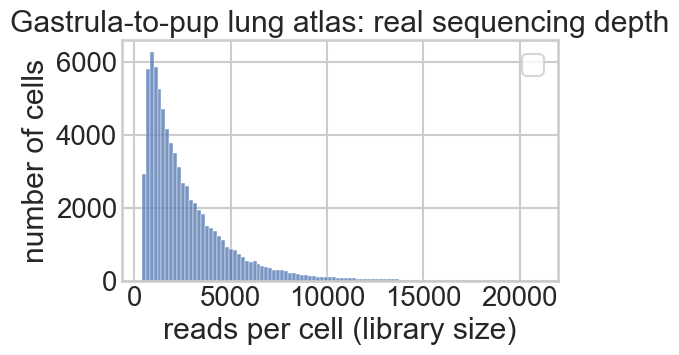

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(noise_library_sizes, bins=100, ax=ax)
# ax.axvline(ASSUMED_LIBRARY_SIZE, color='red', linestyle='--', label=f'assumed depth ({ASSUMED_LIBRARY_SIZE:,})')
ax.legend()
ax.set_xlabel('reads per cell (library size)')
ax.set_ylabel('number of cells')
ax.set_title('Gastrula-to-pup lung atlas: real sequencing depth')
plt.tight_layout()
plt.show()

## 5. Reconstruct counts, add noise, and re-score

In [10]:
def reconstruct_counts(z_state, library_size, rng):
    """Step 1: reconstruct RNA counts from a z-score state. top.process only
    preserves gene rank order, so we mix the three real reference profiles using
    the state's current attractor weights, then assign counts by matching the
    simulated gene rank order to the (sorted) mixed reference profile."""
    m_up = (1 / noise_network.N) * noise_network.attractors.dot(z_state)
    weights = np.clip(noise_network.inv_corr.dot(m_up), 0, None)
    weights = weights / weights.sum() if weights.sum() > 0 else np.full(3, 1 / 3)

    mixture_profile = sum(w * noise_reference_profiles[label]
                           for w, label in zip(weights, ['at1', 'at2', 'early epithelium']))

    rank_position = z_state.loc[noise_ref_genes].rank(method='first').astype(int) - 1
    base_counts = pd.Series(np.sort(mixture_profile.values)[rank_position.values], index=noise_ref_genes)
    return base_counts * (library_size / base_counts.sum())


def add_biological_noise(counts, bio_cv, rng):
    """Step 2: Splatter-style Gamma-Poisson biological noise."""
    shape = 1 / bio_cv**2
    gamma_factor = rng.gamma(shape=shape, scale=1 / shape, size=len(counts))
    return rng.poisson(counts.values * gamma_factor)


def add_technical_dropout(counts, base_counts, dropout_shift, rng, shape=-1):
    """Step 3: Splatter-style expression-dependent logistic dropout."""
    log_mean = np.log1p(base_counts)
    midpoint = np.median(log_mean) + dropout_shift
    dropout_prob = 1 / (1 + np.exp(-shape * (log_mean - midpoint)))
    keep = rng.random(len(counts)) > dropout_prob
    return counts * keep


def sample_steps_per_trial(n_steps, trajectory_length, rng):
    """Stratified random sampling: split the trajectory into n_steps equal bins
    and draw one random step from each bin. Every trial gets a different,
    slightly offset set of steps that still spans the whole trajectory."""
    bin_edges = np.linspace(0, trajectory_length, n_steps + 1).astype(int)
    return np.array([rng.integers(bin_edges[i], max(bin_edges[i] + 1, bin_edges[i + 1]))
                     for i in range(n_steps)])

def simulate_noisy_cells(n_steps, bio_cv=0.1, dropout_shift=0, rng=None):
    """Steps 1-4: for EVERY trial trajectory, randomly sample n_steps time
    points (stratified, so each trial's steps are slightly offset from the
    others), reconstruct counts, add biological + technical noise (one
    instance per cell), then re-process with scTOP and return the resulting
    (at1, at2, early epithelium) scores."""
    rng = rng or np.random.default_rng()

    noisy_cells = {}
    for trial, trajectory in enumerate(noise_trajectories):
        steps = sample_steps_per_trial(n_steps, len(trajectory), rng)
        for step in steps:
            z_state = trajectory.iloc[step]
            base_counts = reconstruct_counts(z_state, ASSUMED_LIBRARY_SIZE, rng)
            bio_counts = add_biological_noise(base_counts, bio_cv, rng)
            noisy_cells[f'trial{trial}_step{step}'] = add_technical_dropout(
                bio_counts, base_counts.values, dropout_shift, rng)
    noisy_cells = pd.DataFrame(noisy_cells, index=noise_ref_genes)

    processed = top.process(noisy_cells)
    scores = top.score(new_basis, processed).T
    return scores


# Number of steps to sample per trial (each trial gets its own random set)
noise_steps_per_trial = 5

In [11]:
def simulate_noiseless_trajectory(num_trials=None):
    """Reference paths: reconstructed counts with NO biological or technical
    noise added, computed at every step of every trial trajectory, processed
    and scored together (same pipeline as the noisy realizations). Returns a
    DataFrame with a (trial, step) MultiIndex so each trial's path can be
    plotted as its own line."""
    base_counts = {}
    if num_trials is not None:
        for trial, trajectory in zip(range(num_trials), noise_trajectories):
                for step in range(len(trajectory)):
                    base_counts[(trial, step)] = reconstruct_counts(trajectory.iloc[step], ASSUMED_LIBRARY_SIZE, noise_rng)
    else:
        for trial, trajectory in enumerate(noise_trajectories):
            for step in range(len(trajectory)):
                base_counts[(trial, step)] = reconstruct_counts(trajectory.iloc[step], ASSUMED_LIBRARY_SIZE, noise_rng)
                
    base_counts = pd.DataFrame(base_counts, index=noise_ref_genes)
    base_counts.columns = pd.MultiIndex.from_tuples(base_counts.columns, names=['trial', 'step'])

    processed = top.process(base_counts)
    scores = top.score(new_basis, processed).T
    scores.index = base_counts.columns
    return scores


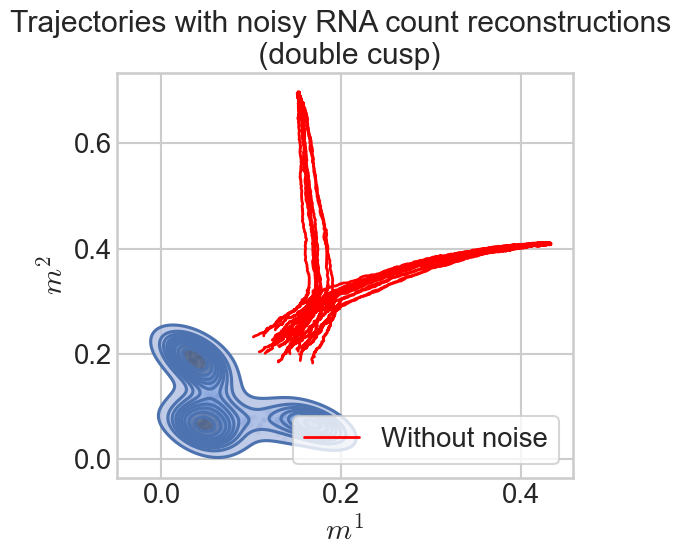

In [12]:
# Sanity check: a single noise setting (default bio_cv, no dropout shift), noise
# sampled across the whole trajectory, with all trials' noiseless trajectories overlaid
noise_scores = simulate_noisy_cells(noise_steps_per_trial, bio_cv=0.1, dropout_shift=0.1, rng=noise_rng)
noiseless_trajectory = simulate_noiseless_trajectory(num_trials=20)
 
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=noise_scores['Lung AT1 Cell WK6 KO22'], y=noise_scores['Lung AT2 Cell WK6 KO22'], color=sns.color_palette()[0], alpha=0.25, s=15, ax=ax)
sns.kdeplot(x=noise_scores['Lung AT1 Cell WK6 KO22'], y=noise_scores['Lung AT2 Cell WK6 KO22'], fill=True, alpha=0.8, ax=ax)
sns.kdeplot(x=noise_scores['Lung AT1 Cell WK6 KO22'], y=noise_scores['Lung AT2 Cell WK6 KO22'], ax=ax)
for trial in noiseless_trajectory.index.get_level_values('trial').unique():
    path = noiseless_trajectory.loc[trial]
    ax.plot(path['Lung AT1 Cell WK6 KO22'], path['Lung AT2 Cell WK6 KO22'], color='red', linewidth=2, zorder=5, label='Without noise' if trial == 0 else None)
ax.legend()
# ax.set_aspect('equal')
# ax.set_xlim((-0.5,1.5))
# ax.set_ylim((-0.5,1.5))
ax.set_xlabel('$m^1$')
ax.set_ylabel('$m^2$')

ax.set_title('Trajectories with noisy RNA count reconstructions \n (double cusp)')
plt.tight_layout()
plt.savefig('./figs/noisy vs noiseless trajectories.png', dpi=300)
plt.show()

## 6. Matrix of contour plots: technical noise (columns) x biological noise (rows)

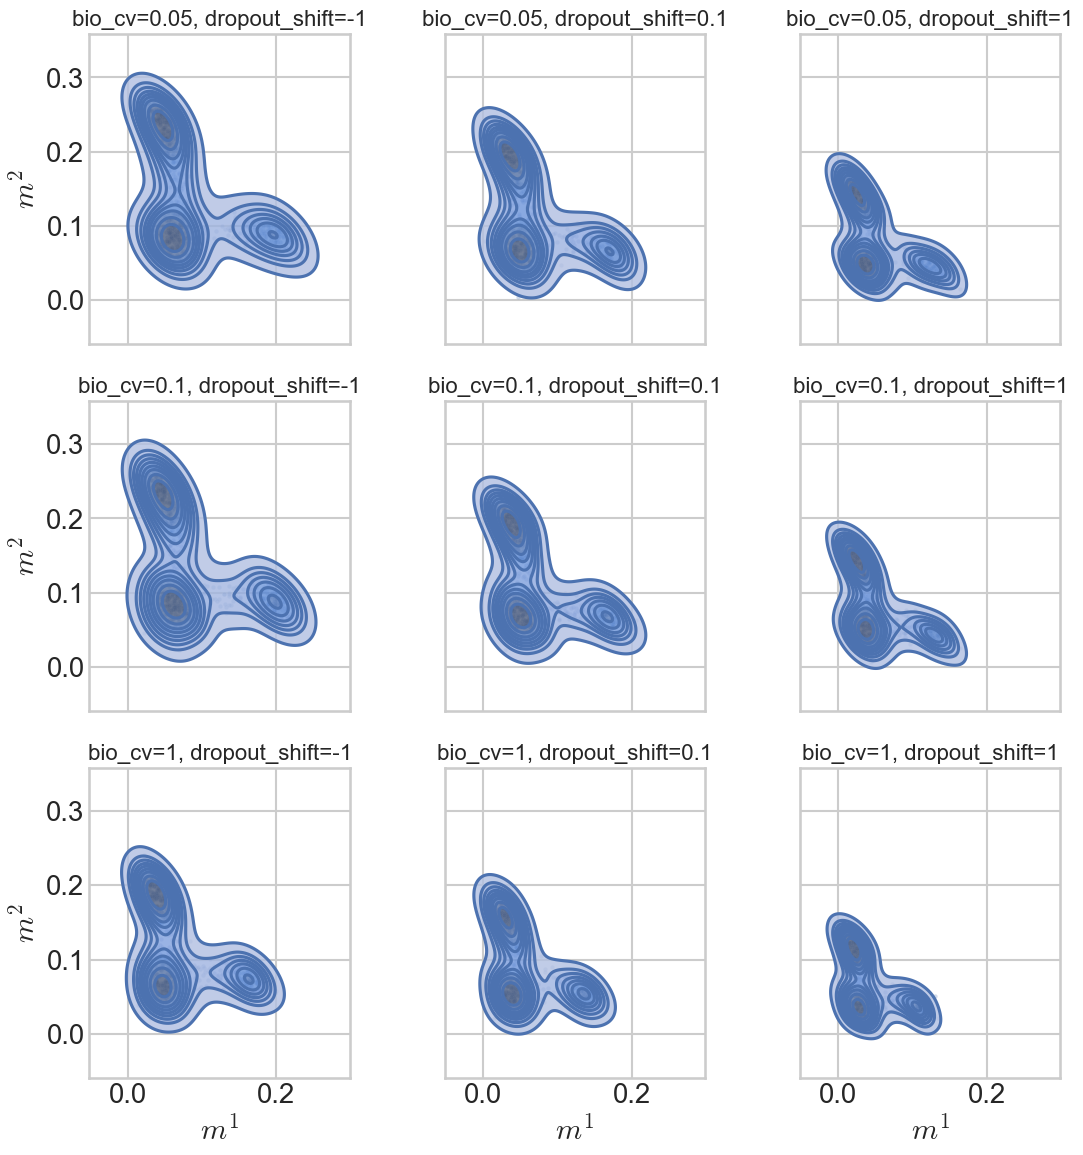

In [13]:
bio_cv_values = [0.05, 0.1, 1]
dropout_shift_values = [-1, 0.1, 1]
# noiseless_trajectory = simulate_noiseless_trajectory()
# noiseless_trials = noiseless_trajectory.index.get_level_values('trial').unique()

fig, axes = plt.subplots(len(bio_cv_values), len(dropout_shift_values),
                          sharex=True, sharey=True, figsize=(12, 12))

for row, bio_cv in enumerate(bio_cv_values):
    for col, dropout_shift in enumerate(dropout_shift_values):
        ax = axes[row, col]
        scores = simulate_noisy_cells(noise_steps_per_trial, bio_cv=bio_cv, dropout_shift=dropout_shift, rng=noise_rng)

        sns.scatterplot(x=scores['Lung AT1 Cell WK6 KO22'], y=scores['Lung AT2 Cell WK6 KO22'], color=sns.color_palette()[0], alpha=0.25, s=10, ax=ax)
        sns.kdeplot(x=scores['Lung AT1 Cell WK6 KO22'], y=scores['Lung AT2 Cell WK6 KO22'], fill=True, alpha=0.8, ax=ax)
        sns.kdeplot(x=scores['Lung AT1 Cell WK6 KO22'], y=scores['Lung AT2 Cell WK6 KO22'], ax=ax)
        # for trial in noiseless_trials:
        #     path = noiseless_trajectory.loc[trial]
        #     ax.plot(path['Lung AT1 Cell WK6 KO22'], path['Lung AT2 Cell WK6 KO22'], color='red', linewidth=1.5, zorder=5)
        ax.set_aspect('equal')
        # ax.set_xlim((0, 1))
        # ax.set_ylim((0, 1))
        ax.set_title(f'bio_cv={bio_cv}, dropout_shift={dropout_shift}', fontsize=16)
        ax.set_xlabel('$m^1$' if row == len(bio_cv_values) - 1 else '')
        ax.set_ylabel('$m^2$' if col == 0 else '')


plt.tight_layout()
plt.savefig('./noise simulations grid.png', dpi=300)
plt.show()

## 7. Triple cusp, for comparison

100%|██████████| 100/100 [02:39<00:00,  1.59s/it]


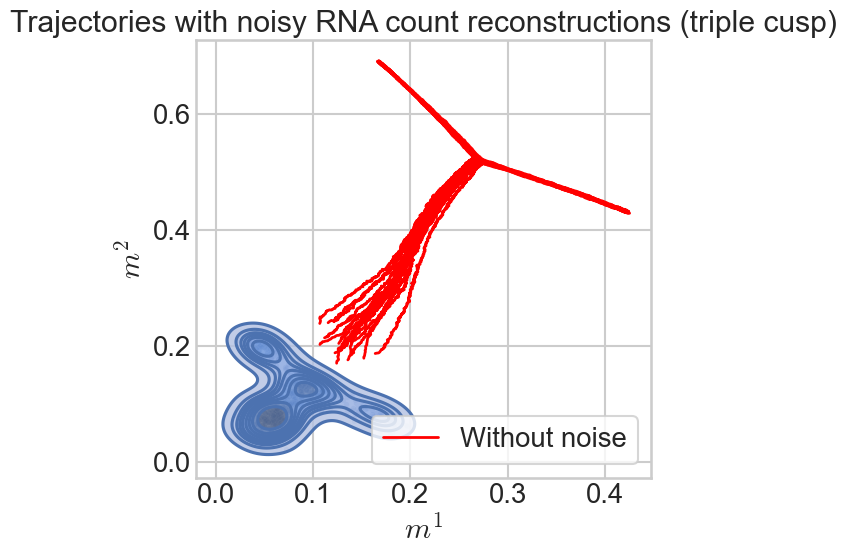

In [14]:
# --- Re-run trajectories with the TRIPLE cusp landscape (settings from
#     "noise simulations.ipynb": f ramps 600->700 to +/-0.3, k ramps 0->400 to 0.3) ---
triple_landscape_args = {'start_params': {'f': 0, 'k': 0},
                         'attractor_coords': [[0, triple_cusp_coords['y0']],
                                              [triple_cusp_coords['x1'], triple_cusp_coords['y1']]],
                         'gradients': triple_cusp_grad}

noise_trajectories = []
for _ in trange(noise_n_trials):
    noise_dynamics_args = {'stored_states': attractor_states.T,
                           'initial_state': attractor_states['early epithelium'] + noise_rng.standard_normal(size=N)}
    noise_simulation_args = {'total_time': 1000,
                             'signal_bounds': {'start': {'f': 600, 'k': 0}, 'end': {'f': 700, 'k': 400}},
                             'finish_params': {'f': noise_rng.choice([-0.3, 0.3]), 'k': 0.3}}
    trajectory, noise_network = run_trajectory_with_full_state(
        noise_dynamics_args, triple_landscape_args, noise_simulation_args)
    noise_trajectories.append(trajectory)

# --- Same figure as above: noisy cells + noiseless trajectory overlay ---
noise_scores = simulate_noisy_cells(noise_steps_per_trial, bio_cv=0.1, dropout_shift=0.1, rng=noise_rng)
noiseless_trajectory = simulate_noiseless_trajectory(num_trials=20)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=noise_scores['Lung AT1 Cell WK6 KO22'], y=noise_scores['Lung AT2 Cell WK6 KO22'], color=sns.color_palette()[0], alpha=0.25, s=15, ax=ax)
sns.kdeplot(x=noise_scores['Lung AT1 Cell WK6 KO22'], y=noise_scores['Lung AT2 Cell WK6 KO22'], fill=True, alpha=0.8, ax=ax)
sns.kdeplot(x=noise_scores['Lung AT1 Cell WK6 KO22'], y=noise_scores['Lung AT2 Cell WK6 KO22'], ax=ax)
for trial in noiseless_trajectory.index.get_level_values('trial').unique():
    path = noiseless_trajectory.loc[trial]
    ax.plot(path['Lung AT1 Cell WK6 KO22'], path['Lung AT2 Cell WK6 KO22'], color='red', linewidth=2, zorder=5, label='Without noise' if trial == 0 else None)
ax.legend()
# ax.set_aspect('equal')
# ax.set_xlim((-0.5,1.5))
# ax.set_ylim((-0.5,1.5))
ax.set_xlabel('$m^1$')
ax.set_ylabel('$m^2$')

ax.set_title('Trajectories with noisy RNA count reconstructions (triple cusp)')
plt.tight_layout()
plt.savefig('./figs/noisy vs noiseless trajectories (triple cusp).png', dpi=300)
plt.show()

# Plot the simulated count distributions next to real ones to compare

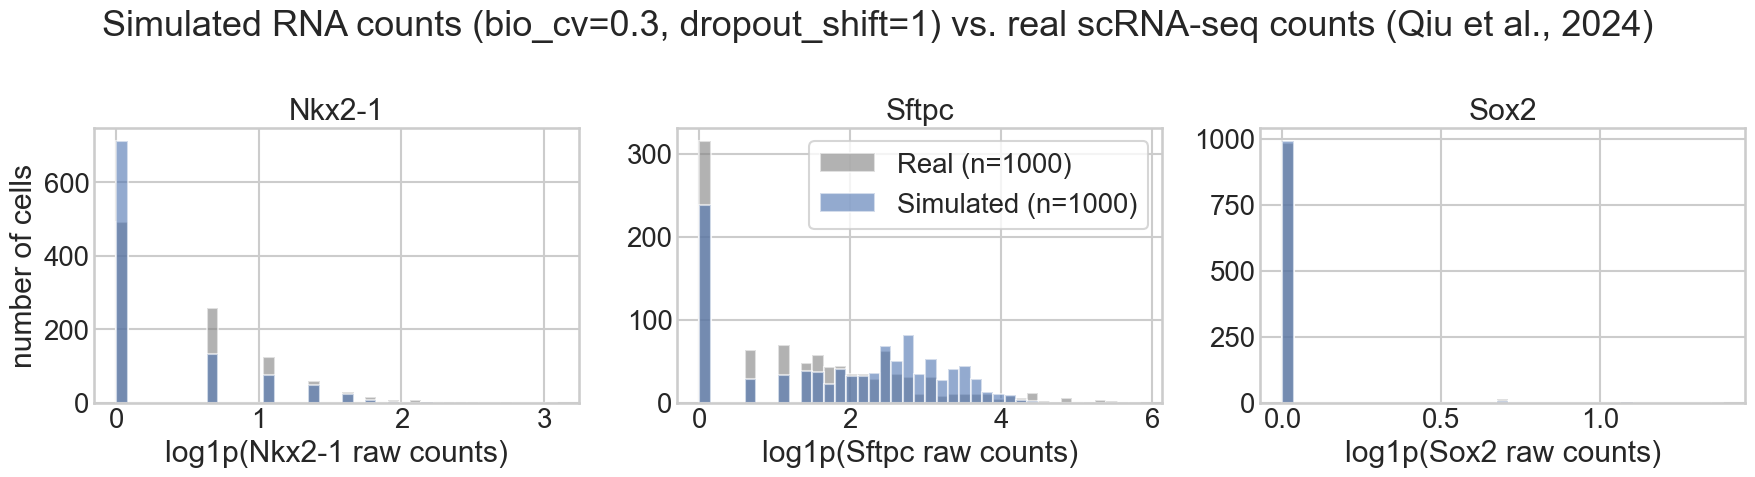

In [18]:
from scipy import sparse

genes = ['Nkx2-1', 'Sftpc', 'Sox2']
example_bio_cv = 0.3
example_dropout_shift = 1
compare_steps = np.linspace(0, len(noise_trajectories[0]) - 1, 10).astype(int)

ASSUMED_LIBRARY_SIZE = 5000

# --- Simulated cells: one noisy realization per trial at each compared step ---
# (same cells used for all genes, so panels are directly comparable)
sim_cells = []
for trial, trajectory in enumerate(noise_trajectories):
    for step in compare_steps:
        z_state = trajectory.iloc[step]
        base = reconstruct_counts(z_state, ASSUMED_LIBRARY_SIZE, noise_rng)
        bio = add_biological_noise(base, example_bio_cv, noise_rng)
        sim_cells.append(add_technical_dropout(bio, base.values, example_dropout_shift, noise_rng))
sim_cells = np.array(sim_cells)  # cells x genes

# --- Real cells of all three types, restricted to the same reference genes ---
obs_mask = _noise_real_data.obs['author_cell_type'].isin(_noise_cell_type_map.values()).values
var_mask = _noise_real_data.var['feature_name'].isin(noise_ref_genes).values
real_sub = _noise_real_data[obs_mask][:, var_mask]
real_idx = noise_rng.choice(real_sub.n_obs, size=len(sim_cells), replace=False)

# --- Plot: one panel per gene ---
fig, axes = plt.subplots(1, len(genes), figsize=(6 * len(genes), 5), sharey=False)

for ax, gene in zip(axes, genes):
    gene_idx = np.where(noise_ref_genes == gene)[0][0]
    sim_gene_counts = sim_cells[:, gene_idx]

    var_mask = (real_sub.var['feature_name'] == gene).values
    X = real_sub[real_idx][:, var_mask].layers['raw.X']
    X = X.toarray() if sparse.issparse(X) else np.asarray(X)
    real_gene_counts = X.flatten()

    bins = np.linspace(0, np.log1p(max(real_gene_counts.max(), sim_gene_counts.max())), 40)

    ax.hist(np.log1p(real_gene_counts), bins=bins, color='gray', alpha=0.6,
            label=f'Real (n={len(real_gene_counts)})')
    ax.hist(np.log1p(sim_gene_counts), bins=bins, color=sns.color_palette()[0], alpha=0.6,
            label=f'Simulated (n={len(sim_gene_counts)})')

    ax.set_xlabel(f'log1p({gene} raw counts)')
    ax.set_title(gene)
    # ax.legend()

axes[0].set_ylabel('number of cells')
axes[1].legend()

fig.suptitle(f'Simulated RNA counts (bio_cv={example_bio_cv}, '
             f'dropout_shift={example_dropout_shift}) vs. real scRNA-seq counts (Qiu et al., 2024)')
plt.tight_layout()

plt.savefig('./figs/simulated count comparison.pdf', dpi=300)
plt.show()